In [ ]:
# Install (only if needed)
# !pip install pandas numpy matplotlib seaborn statsmodels prophet scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("charging_ev_and_grid_optimization_dataset.csv")

print(df.shape)
df.head()

(8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,01-01-2025 00:00,ST004,Urban,EV10000,Two-Wheeler,01-01-2025 00:00,01-01-2025 00:12,01-01-2025 04:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,01-01-2025 00:15,ST005,Urban,EV10001,Two-Wheeler,01-01-2025 00:15,01-01-2025 00:23,01-01-2025 01:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,01-01-2025 00:30,ST019,Highway,EV10002,Car,01-01-2025 00:30,01-01-2025 00:41,01-01-2025 01:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,01-01-2025 00:45,ST008,Urban,EV10003,Two-Wheeler,01-01-2025 00:45,01-01-2025 00:54,01-01-2025 03:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,01-01-2025 01:00,ST008,Highway,EV10004,Two-Wheeler,01-01-2025 01:00,01-01-2025 01:08,01-01-2025 06:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

,0
timestamp,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
waiting_time,0
battery_capacity_kWh,0


In [ ]:
# Convert datetime
# If 'timestamp' is currently the index, reset it to make it a column for processing.
if df.index.name == 'timestamp':
    df = df.reset_index()

df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

# Sort values
df = df.sort_values('timestamp')

# Handle missing values
df = df.ffill()

# Rename target column if needed
# The actual column name is 'energy_consumed_kWh'
if 'energy_consumed_kWh' in df.columns:
    df.rename(columns={'energy_consumed_kWh': 'demand'}, inplace=True)

# Set index
df.set_index('timestamp', inplace=True)

In [ ]:
# Time features
df['hour'] = df.index.hour
df['day'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day'].isin([5,6]).astype(int)

# Lag features
df['lag_1'] = df['demand'].shift(1)
df['lag_2'] = df['demand'].shift(2)

# Rolling mean
df['rolling_mean_3'] = df['demand'].rolling(3).mean()

# Drop NA
df.dropna(inplace=True)

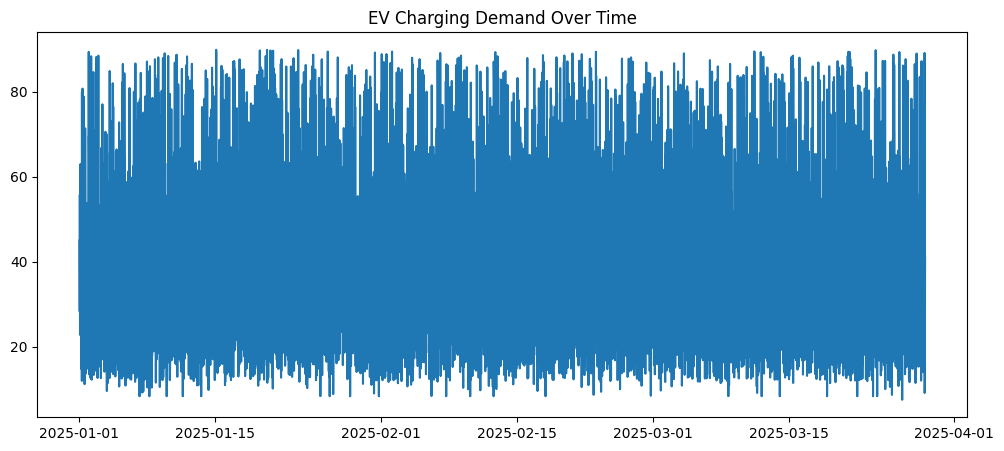

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['demand'])
plt.title("EV Charging Demand Over Time")
plt.show()

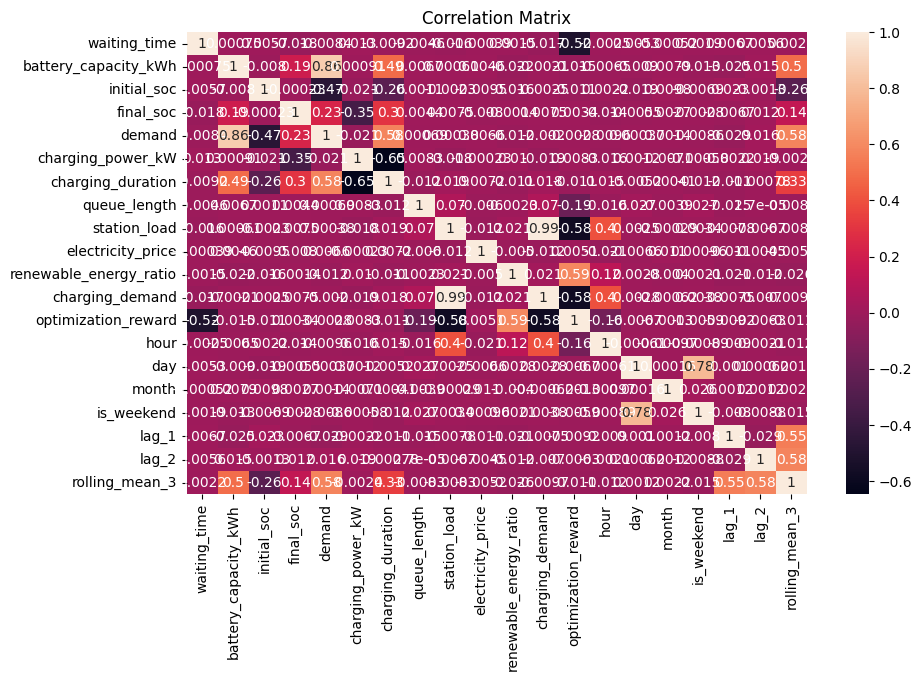

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [ ]:
##ARIMA MODEL
model = ARIMA(train['demand'], order=(2,1,2))
model_fit = model.fit()

forecast_arima = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


In [ ]:
mae_arima = mean_absolute_error(test['demand'], forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test['demand'], forecast_arima))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 15.659388860395623
ARIMA RMSE: 18.893053849901857


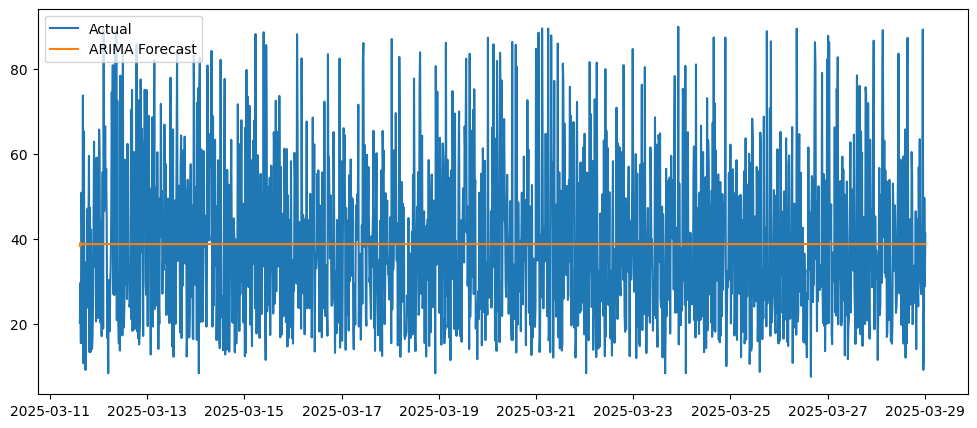

In [ ]:
## PLOT
plt.figure(figsize=(12,5))
plt.plot(test.index, test['demand'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.show()

In [ ]:
## PROPHET MODEL
df_prophet = df.reset_index()[['timestamp','demand','traffic_density']]

df_prophet.rename(columns={
    'timestamp':'ds',
    'demand':'y'
}, inplace=True)

In [ ]:
# One-hot encode 'traffic_density' to convert it into numerical features
df_prophet_encoded = pd.get_dummies(df_prophet, columns=['traffic_density'], prefix='traffic')

model_p = Prophet()

# Add the newly created one-hot encoded columns as regressors
regressor_cols = [col for col in df_prophet_encoded.columns if col.startswith('traffic_')]
for col in regressor_cols:
    model_p.add_regressor(col)

model_p.fit(df_prophet_encoded)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [ ]:
## FORECAST
future = model_p.make_future_dataframe(periods=48, freq='h')

# Assign the last observed values of the one-hot encoded traffic density features to the future dataframe
for col in regressor_cols:
    future[col] = df_prophet_encoded[col].iloc[-1]

forecast_prophet = model_p.predict(future)

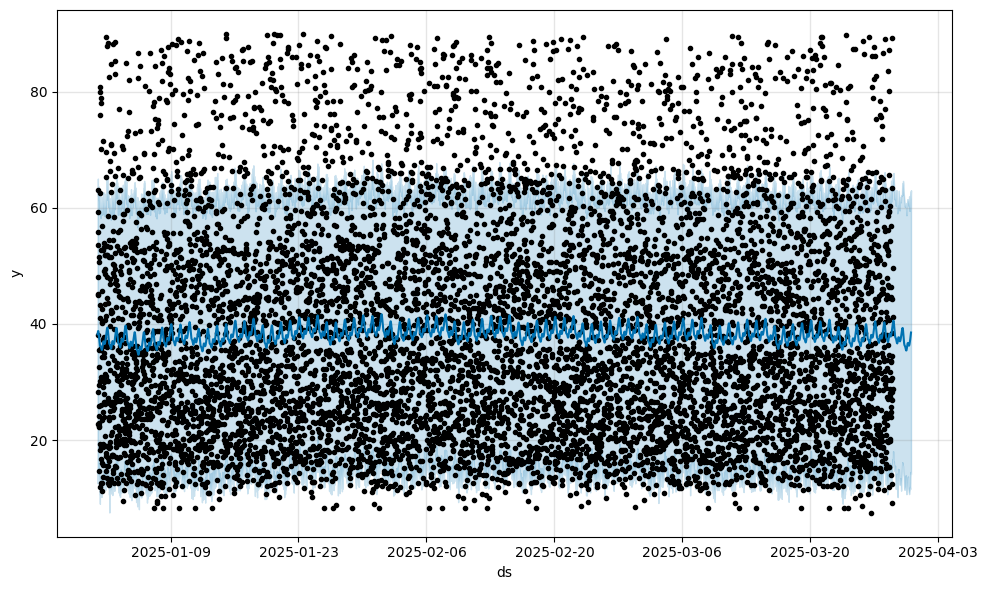

In [ ]:
## PLOT
model_p.plot(forecast_prophet)
plt.show()

In [ ]:
pred = forecast_prophet['yhat'][:len(df_prophet)]

mae_prophet = mean_absolute_error(df_prophet['y'], pred)
rmse_prophet = np.sqrt(mean_squared_error(df_prophet['y'], pred))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

Prophet MAE: 15.637818054448617
Prophet RMSE: 18.97451879408325


In [ ]:
# Forecast output
forecast_prophet[['ds','yhat']].to_csv("forecast_output.csv", index=False)

# Clean dataset
df.to_csv("cleaned_ev_data.csv")